# 1주차

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

DATA_DIR = Path('.')
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

TARGET = 'health_condition'
LABELS = ['at-risk', 'fit', 'unhealthy']
COLORS = ['#587894', '#209A83', '#D67B59']
numeric_cols = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
                'step_count', 'exercise_duration', 'water_intake']
categorical_cols = ['diet_type', 'stress_level', 'sleep_quality',
                   'physical_activity_level', 'smoking_alcohol', 'gender']
feature_cols = numeric_cols + categorical_cols

print('train:', train.shape)
print('test:', test.shape)
print('scikit-learn:', sklearn.__version__)
display(train.head())

train: (690088, 15)
test: (295753, 14)
scikit-learn: 1.9.0


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## 결측치/중복값 파악

In [2]:
assert train.shape == (690088, 15), 'train 파일이 온전한지 확인하세요.'
assert test.shape == (295753, 14), 'test 파일이 온전한지 확인하세요.'
assert train[TARGET].notna().all(), '정답에 빈칸이 있는지 확인하세요.'
assert set(train[TARGET]) == set(LABELS)
assert set(test.columns) == set(feature_cols + ['id'])
assert train['id'].is_unique and test['id'].is_unique
assert set(train['id']).isdisjoint(set(test['id']))

missing = pd.DataFrame({
    'dtype': train[feature_cols].dtypes.astype(str),
    'missing_n': train[feature_cols].isna().sum(),
    'train_missing_pct': train[feature_cols].isna().mean()*100,
    'test_missing_pct': test[feature_cols].isna().mean()*100,
}).sort_values('train_missing_pct', ascending=False)
display(missing.round(2))
print('완전히 같은 추가 행:', train.duplicated().sum())
print('id를 제외했을 때 같은 추가 행:', train.drop(columns='id').duplicated().sum())
print('입력 변수만 같은 추가 행:', train[feature_cols].duplicated().sum())

,dtype,missing_n,train_missing_pct,test_missing_pct
stress_level,str,82811,12.00,12.00
sleep_duration,float64,75999,11.01,11.01
sleep_quality,str,58331,8.45,8.45
calorie_expenditure,float64,52853,7.66,7.66
water_intake,float64,43477,6.30,6.30
physical_activity_level,str,36621,5.31,5.31
smoking_alcohol,str,28582,4.14,4.14
gender,str,21373,3.10,3.10
step_count,float64,13916,2.02,2.02
bmi,float64,13898,2.01,2.01


완전히 같은 추가 행: 0
id를 제외했을 때 같은 추가 행: 0
입력 변수만 같은 추가 행: 0


In [3]:
from sklearn.model_selection import train_test_split

X = train[feature_cols].copy()
y = train[TARGET].copy()
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

eda = X_train.copy()
eda[TARGET] = y_train
print('학습용:', X_train.shape)
print('검증용:', X_valid.shape)
assert X_train.index.intersection(X_valid.index).empty

학습용: (552070, 13)
검증용: (138018, 13)


## EDA1. at-risk라 찍어도 맞는 결과가 나올 수 있지 않은가?

,n,pct
health_condition,,
at-risk,474049,85.87
fit,31842,5.77
unhealthy,46179,8.36


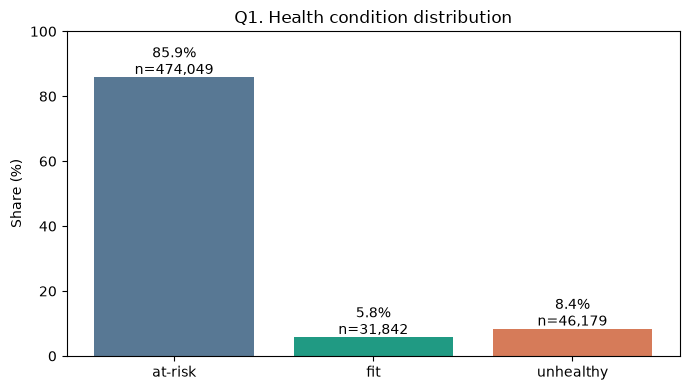

In [4]:
class_table = y_train.value_counts().reindex(LABELS).to_frame('n')
class_table['pct'] = class_table['n'] / len(y_train)*100
display(class_table.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(LABELS, class_table['pct'], color=COLORS)
for bar, pct, n in zip(bars, class_table['pct'], class_table['n']):
    ax.text(bar.get_x()+bar.get_width()/2, pct+1,
            f'{pct:.1f}%\nn={n:,}', ha='center', fontsize=10)
ax.set(title='Q1. Health condition distribution', ylabel='Share (%)', ylim=(0, 100))
fig.tight_layout()
plt.show()

## EDA1-A) balanced accuracy 적용 필요

## EDA2. 수치형 건강 지표 중 어떤 변수가 건강 상태를 분류하는 데 있어 중요한가?

,count,mean,std,min,25%,50%,75%,max
sleep_duration,491368.0,6.99,1.22,3.0,6.16,6.99,7.81,10.00
heart_rate,545874.0,75.10,8.18,50.0,69.40,75.10,80.70,107.70
bmi,540984.0,22.98,2.48,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,509948.0,2226.13,347.63,1201.0,2052.00,2240.00,2457.00,3580.00
step_count,540949.0,8614.06,3930.60,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,546559.0,38.76,14.74,0.0,29.20,39.40,49.40,99.80
water_intake,517205.0,2.19,0.52,0.5,1.85,2.17,2.50,4.72


health_condition,at-risk,fit,unhealthy
sleep_duration,7.03,7.84,5.53
heart_rate,75.10,74.50,75.10
bmi,22.96,22.26,23.69
calorie_expenditure,2235.00,2344.00,2255.00
step_count,8484.00,12309.00,8934.00
exercise_duration,38.60,50.50,39.70
water_intake,2.18,2.15,2.17


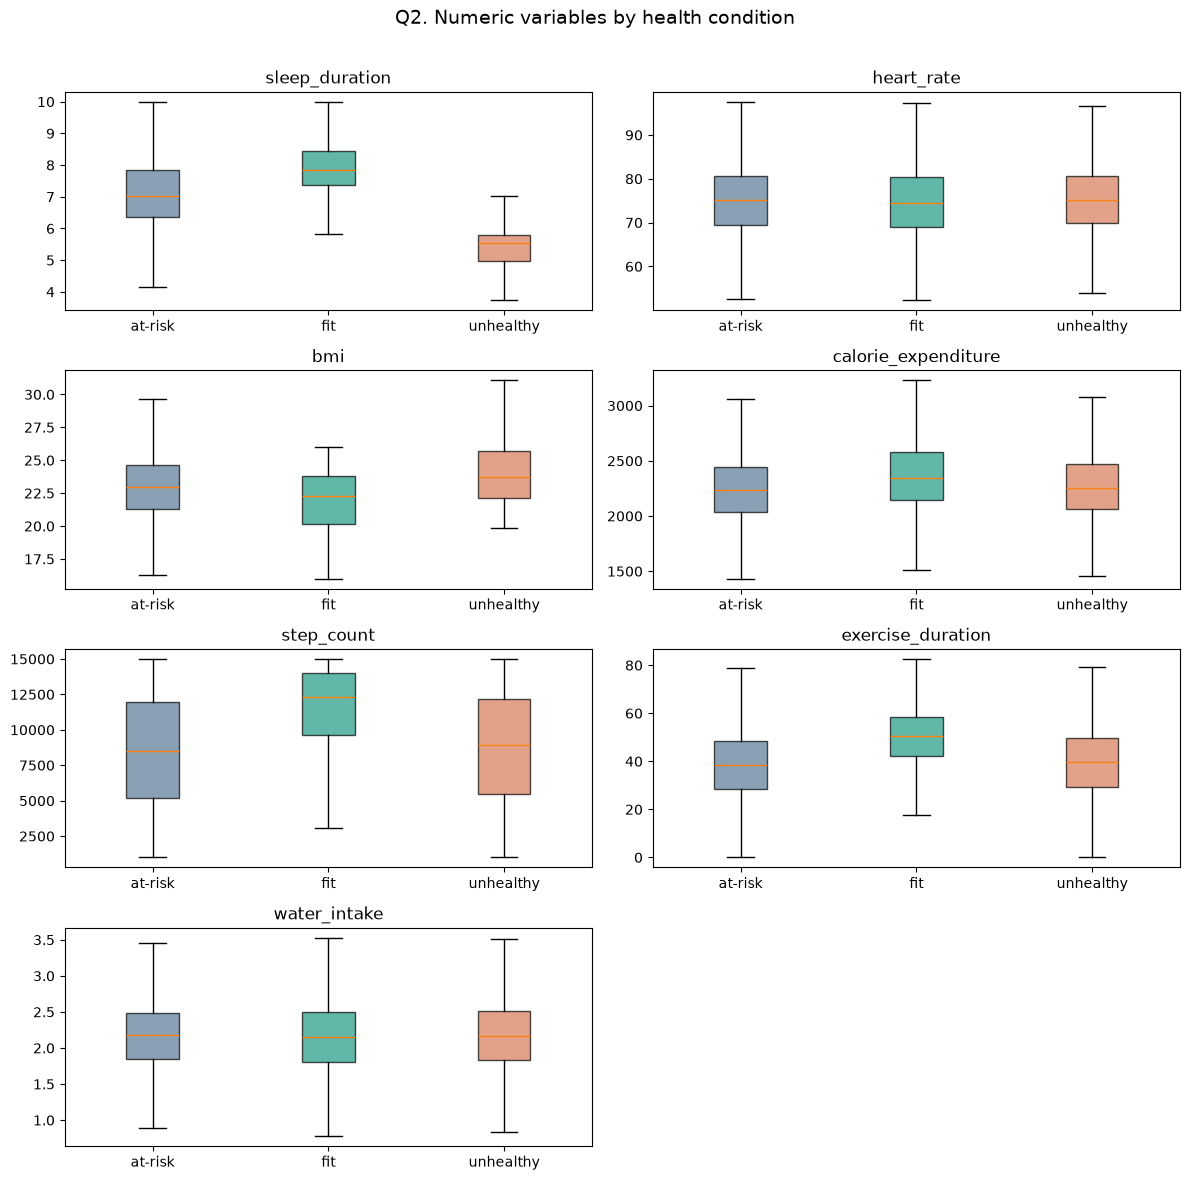

In [5]:
display(X_train[numeric_cols].describe().T.round(2))
numeric_medians = eda.groupby(TARGET)[numeric_cols].median().reindex(LABELS).T
display(numeric_medians.round(2))

fig, axes = plt.subplots(4, 2, figsize=(12, 12))
for ax, col in zip(axes.flat, numeric_cols):
    groups = [eda.loc[eda[TARGET] == label, col].dropna() for label in LABELS]
    boxes = ax.boxplot(groups, patch_artist=True, showfliers=False)
    for box, color in zip(boxes['boxes'], COLORS):
        box.set_facecolor(color)
        box.set_alpha(0.7)
    ax.set_xticks([1, 2, 3], LABELS)
    ax.set_title(col)
axes.flat[-1].set_visible(False)
fig.suptitle('Q2. Numeric variables by health condition', fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

## EDA2-A. sleep_duration, exercise_duration, step_count

## EDA2-1. sleep_duration 심화

,n,at-risk,fit,unhealthy
sleep_band,,,,
<5,26534,59.38,0.24,40.39
5-6,81120,64.11,0.22,35.67
6-7,138824,98.99,0.44,0.57
7-8,139255,88.60,11.10,0.30
8-9,78274,88.38,11.43,0.20
9+,27361,88.41,11.26,0.33


수면값이 없어 이 표에서 제외한 행: 60702


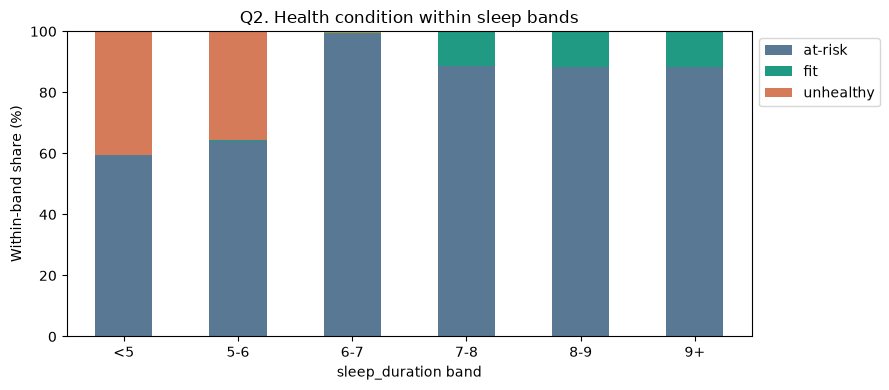

In [6]:
sleep_rows = eda[['sleep_duration', TARGET]].dropna().copy()
sleep_labels = ['<5', '5-6', '6-7', '7-8', '8-9', '9+']
sleep_rows['sleep_band'] = pd.cut(
    sleep_rows['sleep_duration'], [-np.inf, 5, 6, 7, 8, 9, np.inf],
    labels=sleep_labels, right=False
)
sleep_counts = pd.crosstab(sleep_rows['sleep_band'], sleep_rows[TARGET]).reindex(
    index=sleep_labels, columns=LABELS, fill_value=0)
sleep_pct = sleep_counts.div(sleep_counts.sum(axis=1), axis=0)*100
display(sleep_counts.sum(axis=1).to_frame('n').join(sleep_pct).round(2))
print('수면값이 없어 이 표에서 제외한 행:', eda['sleep_duration'].isna().sum())

ax = sleep_pct.plot(kind='bar', stacked=True, color=COLORS, figsize=(9, 4), rot=0)
ax.set(title='Q2. Health condition within sleep bands', ylabel='Within-band share (%)',
       xlabel='sleep_duration band', ylim=(0, 100))
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## EDA3. 어떤 생활 습관이 건강 상태 판단에 중요한 요소인가?

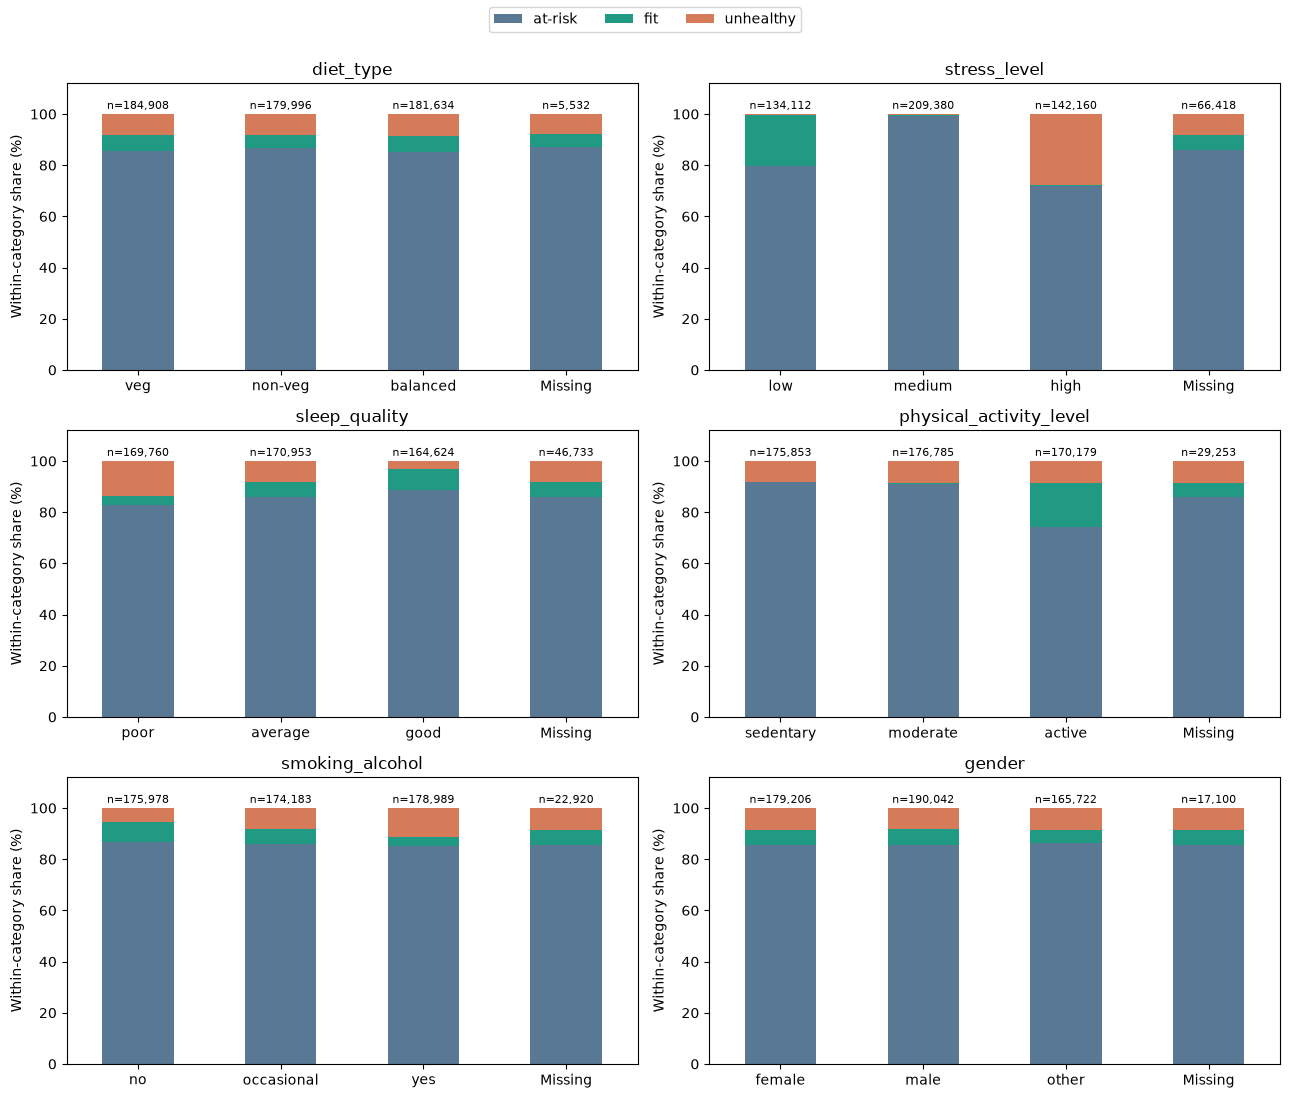


 diet_type


,n,at-risk,fit,unhealthy
diet_type,,,,
veg,184908,85.63,6.03,8.35
non-veg,179996,86.76,5.17,8.08
balanced,181634,85.19,6.12,8.68
Missing,5532,87.06,5.06,7.88



 stress_level


,n,at-risk,fit,unhealthy
stress_level,,,,
low,134112,79.67,20.05,0.27
medium,209380,99.38,0.30,0.32
high,142160,71.79,0.35,27.87
Missing,66418,85.92,5.75,8.34



 sleep_quality


...

,n,at-risk,fit,unhealthy
physical_activity_level,,,,
sedentary,175853,91.71,0.24,8.05
moderate,176785,91.16,0.31,8.54
active,170179,74.35,17.16,8.49
Missing,29253,85.78,5.77,8.45



 smoking_alcohol


,n,at-risk,fit,unhealthy
smoking_alcohol,,,,
no,175978,86.69,7.85,5.46
occasional,174183,85.86,5.79,8.35
yes,178989,85.09,3.70,11.22
Missing,22920,85.68,5.79,8.54



 gender


,n,at-risk,fit,unhealthy
gender,,,,
female,179206,85.70,5.76,8.54
male,190042,85.74,6.21,8.05
other,165722,86.20,5.28,8.52
Missing,17100,85.74,5.69,8.57


In [7]:
category_order = {
    'diet_type': ['veg', 'non-veg', 'balanced', 'Missing'],
    'stress_level': ['low', 'medium', 'high', 'Missing'],
    'sleep_quality': ['poor', 'average', 'good', 'Missing'],
    'physical_activity_level': ['sedentary', 'moderate', 'active', 'Missing'],
    'smoking_alcohol': ['no', 'occasional', 'yes', 'Missing'],
    'gender': ['female', 'male', 'other', 'Missing'],
}
category_counts, category_pct = {}, {}
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
for ax, col in zip(axes.flat, categorical_cols):
    groups = eda[col].fillna('Missing')
    counts = pd.crosstab(groups, eda[TARGET]).reindex(
        index=category_order[col], columns=LABELS, fill_value=0)
    pct = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)*100
    category_counts[col], category_pct[col] = counts, pct
    pct.plot(kind='bar', stacked=True, color=COLORS, ax=ax, legend=False, rot=0)
    for i, n in enumerate(counts.sum(axis=1)):
        ax.text(i, 102, f'n={n:,}', ha='center', fontsize=8)
    ax.set(title=col, xlabel='', ylabel='Within-category share (%)', ylim=(0, 112))
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

for col in categorical_cols:
    print('\n', col)
    display(category_counts[col].sum(axis=1).to_frame('n').join(category_pct[col]).round(2))

## EDA4. 변수 간 상관관계 확인

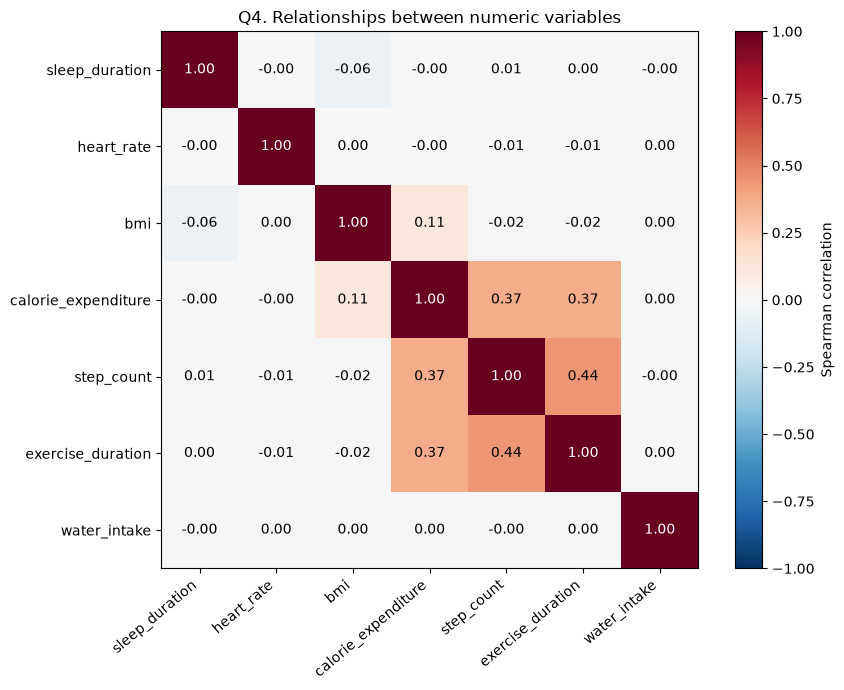

관측 페어 수: 535540 | Spearman 상관: 0.441


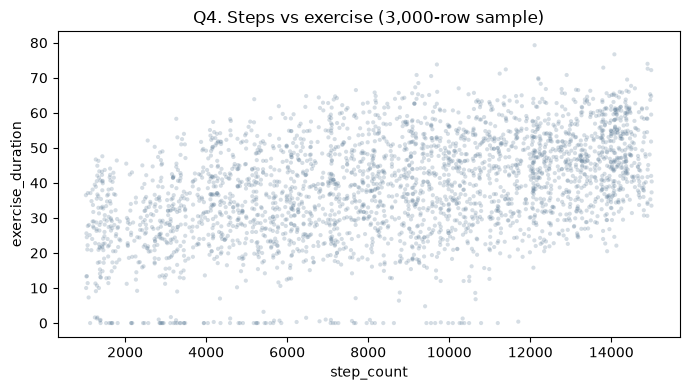

In [8]:
corr = X_train[numeric_cols].corr(method='spearman')
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(numeric_cols)), numeric_cols, rotation=40, ha='right')
ax.set_yticks(range(len(numeric_cols)), numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        value = corr.iloc[i, j]
        ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                color='white' if abs(value) > 0.65 else 'black')
fig.colorbar(im, ax=ax, label='Spearman correlation')
ax.set_title('Q4. Relationships between numeric variables')
fig.tight_layout()
plt.show()

pair = eda[['step_count', 'exercise_duration']].dropna()
rho = pair['step_count'].corr(pair['exercise_duration'], method='spearman')
print('관측 페어 수:', len(pair), '| Spearman 상관:', round(rho, 3))
scatter_sample = pair.sample(n=min(3000, len(pair)), random_state=42)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(scatter_sample['step_count'], scatter_sample['exercise_duration'],
           s=9, alpha=0.25, color='#587894', edgecolors='none')
ax.set(xlabel='step_count', ylabel='exercise_duration', title='Q4. Steps vs exercise (3,000-row sample)')
fig.tight_layout()
plt.show()

## EDA5. 걸음 수가 많아서 fit 비율이 높은 건지, 원래 활동적이라 걸음 수도 많고 fit 도 높은 건지..

,n,fit_pct
step_band,,
<5000,114109,0.25
5000-<10000,190120,4.19
10000+,208054,10.25


n  fit_pct
physical_activity_level step_band                   
active                  5000-<10000   43498    17.38
                        10000+       123272    17.09
moderate                <5000         27947     0.29
                        5000-<10000   74782     0.31
                        10000+        70480     0.32
sedentary               <5000         86162     0.24
                        5000-<10000   71840     0.24
                        10000+        14302     0.22

둘 중 하나 이상 결측이라 제외한 행: 39787


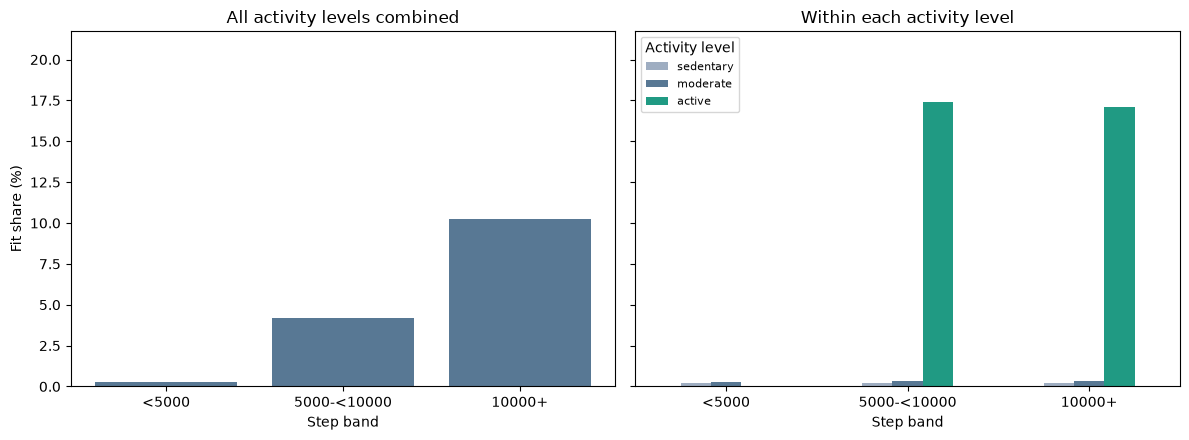

In [9]:
activity_rows = eda[['step_count', 'physical_activity_level', TARGET]].dropna().copy()
step_labels = ['<5000', '5000-<10000', '10000+']
activity_labels = ['sedentary', 'moderate', 'active']
activity_rows['step_band'] = pd.cut(
    activity_rows['step_count'], [-np.inf, 5000, 10000, np.inf],
    labels=step_labels, right=False
)
activity_rows['is_fit'] = (activity_rows[TARGET] == 'fit').astype(int)

overall_steps = activity_rows.groupby('step_band', observed=True)['is_fit'].agg(['size', 'mean'])
overall_steps.columns = ['n', 'fit_ratio']
overall_steps['fit_pct'] = overall_steps['fit_ratio']*100

conditional_steps = activity_rows.groupby(
    ['physical_activity_level', 'step_band'], observed=True)['is_fit'].agg(['size', 'mean'])
conditional_steps.columns = ['n', 'fit_ratio']
conditional_steps['fit_pct'] = conditional_steps['fit_ratio']*100
display(overall_steps[['n', 'fit_pct']].round(2))
display(conditional_steps[['n', 'fit_pct']].round(2))
print('둘 중 하나 이상 결측이라 제외한 행:', len(eda)-len(activity_rows))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].bar(step_labels, overall_steps.reindex(step_labels)['fit_pct'], color='#587894')
axes[0].set(title='All activity levels combined', xlabel='Step band', ylabel='Fit share (%)')
wide = conditional_steps['fit_pct'].unstack('physical_activity_level').reindex(
    index=step_labels, columns=activity_labels)
wide.plot(kind='bar', ax=axes[1], rot=0, color=['#9EADC1', '#587894', '#209A83'])
axes[1].set(title='Within each activity level', xlabel='Step band')
axes[1].legend(title='Activity level', fontsize=8)
axes[0].set_ylim(0, max(overall_steps['fit_pct'].max(), conditional_steps['fit_pct'].max())*1.25)
fig.tight_layout()
plt.show()

## 전처리

In [11]:
outlier_rows = []
for col in numeric_cols:
    values = X_train[col].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    candidates = (values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)
    outlier_rows.append({
        'feature': col,
        'observed_n': len(values),
        'outlier_n': candidates.sum(),
        'outlier_pct_observed': candidates.mean() * 100,
        'min': values.min(),
        'max': values.max(),
    })

outlier_table = pd.DataFrame(outlier_rows).set_index('feature')
display(outlier_table.round(3))

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import clone

numeric_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler()),
])

numeric_rf = SimpleImputer(strategy='median', add_indicator=True)

categorical = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor_lr = ColumnTransformer([
    ('num', numeric_lr, numeric_cols),
    ('cat', clone(categorical), categorical_cols),
])

preprocessor_rf = ColumnTransformer([
    ('num', numeric_rf, numeric_cols),
    ('cat', clone(categorical), categorical_cols),
])

,observed_n,outlier_n,outlier_pct_observed,min,max
feature,,,,,
sleep_duration,491368,1615,0.329,3.0,10.00
heart_rate,545874,2252,0.413,50.0,107.70
bmi,540984,4264,0.788,16.0,34.82
calorie_expenditure,509948,9992,1.959,1201.0,3580.00
step_count,540949,0,0.000,1002.0,14999.00
exercise_duration,546559,82,0.015,0.0,99.80
water_intake,517205,9787,1.892,0.5,4.72


## 모델 비교

In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, accuracy_score, f1_score
from threadpoolctl import threadpool_limits

models = {
    'Dummy': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor_lr),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_rf),
        ('model', RandomForestClassifier(
            n_estimators=100, max_depth=16, min_samples_leaf=2,
            class_weight='balanced_subsample', random_state=42, n_jobs=2)),
    ]),
}

result_rows = []
predictions = {}
for name, model in models.items():
    started = time.perf_counter()
    # CPU 사용을 제한한다. 모델링 개념과는 관계없는 실행 환경 설정이다.
    with threadpool_limits(limits=2):
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)
    predictions[name] = pred
    result_rows.append({
        'model': name,
        'balanced_accuracy': balanced_accuracy_score(y_valid, pred),
        'accuracy': accuracy_score(y_valid, pred),
        'macro_f1': f1_score(y_valid, pred, average='macro'),
        'seconds': time.perf_counter()-started,
    })
    print(name, '완료')

results = pd.DataFrame(result_rows).sort_values('balanced_accuracy', ascending=False)
display(results.round(5))

Dummy 완료
Logistic Regression 완료
Random Forest 완료


,model,balanced_accuracy,accuracy,macro_f1,seconds
2,Random Forest,0.94576,0.94782,0.87994,91.40322
1,Logistic Regression,0.91510,0.84834,0.72570,13.78285
0,Dummy,0.33333,0.85867,0.30799,2.15472


이번 검증에서 선택한 모델: Random Forest


,precision,recall,f1-score,support
at-risk,0.9913,0.9484,0.9693,118512.0000
fit,0.7528,0.9444,0.8378,7961.0000
unhealthy,0.7446,0.9446,0.8327,11545.0000
accuracy,0.9478,0.9478,0.9478,0.9478
macro avg,0.8295,0.9458,0.8799,138018.0000
weighted avg,0.9569,0.9478,0.9503,138018.0000


,at-risk,fit,unhealthy
at-risk,112393,2421,3698
fit,400,7518,43
unhealthy,592,48,10905


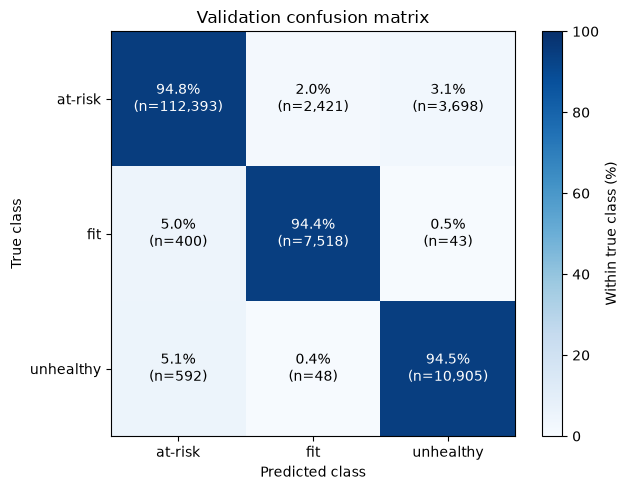

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

best_name = results.iloc[0]['model']
best_pred = predictions[best_name]
report = pd.DataFrame(classification_report(
    y_valid, best_pred, labels=LABELS, output_dict=True, zero_division=0
)).T

print('이번 검증에서 선택한 모델:', best_name)
display(report.round(4))

cm = confusion_matrix(y_valid, best_pred, labels=LABELS)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
display(pd.DataFrame(cm, index=LABELS, columns=LABELS))

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(cm_pct, vmin=0, vmax=100, cmap='Blues')
ax.set_xticks(range(3), LABELS)
ax.set_yticks(range(3), LABELS)

for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{cm_pct[i, j]:.1f}%\n(n={cm[i, j]:,})', ha='center', va='center',
                color='white' if cm_pct[i, j] > 55 else 'black')

ax.set(xlabel='Predicted class', ylabel='True class', title='Validation confusion matrix')
fig.colorbar(im, ax=ax, label='Within true class (%)')
fig.tight_layout()

In [15]:
fitted_preprocessor = models['Random Forest'].named_steps['preprocessor']
preview_array = fitted_preprocessor.transform(X_valid.head(5))
preview = pd.DataFrame(
    preview_array, columns=fitted_preprocessor.get_feature_names_out(),
    index=X_valid.head(5).index
)
print('전처리 전:')
display(X_valid.head(5))
print('전처리 후:', preview.shape, '| 결측 수:', preview.isna().sum().sum())
display(preview.round(3))

전처리 전:


,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
304516,6.82,67.9,27.17,2464.0,13456.0,39.9,2.05,veg,medium,good,moderate,no,other
165358,7.97,92.9,16.86,NaN,7456.0,26.9,2.14,balanced,high,good,moderate,no,female
671841,NaN,NaN,22.18,2352.0,4140.0,19.7,2.33,non-veg,low,poor,sedentary,occasional,male
403460,NaN,83.1,21.93,2620.0,11656.0,41.1,1.22,non-veg,medium,good,moderate,occasional,other
351133,8.14,80.0,23.41,2442.0,4484.0,38.9,2.32,veg,medium,NaN,sedentary,no,other


전처리 후: (5, 38) | 결측 수: 0


,num__sleep_duration,num__heart_rate,num__bmi,num__calorie_expenditure,num__step_count,num__exercise_duration,num__water_intake,num__missingindicator_sleep_duration,num__missingindicator_heart_rate,num__missingindicator_bmi,...,cat__physical_activity_level_moderate,cat__physical_activity_level_sedentary,cat__smoking_alcohol_Missing,cat__smoking_alcohol_no,cat__smoking_alcohol_occasional,cat__smoking_alcohol_yes,cat__gender_Missing,cat__gender_female,cat__gender_male,cat__gender_other
304516,6.82,67.9,27.17,2464.0,13456.0,39.9,2.05,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
165358,7.97,92.9,16.86,2240.0,7456.0,26.9,2.14,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
671841,6.99,75.1,22.18,2352.0,4140.0,19.7,2.33,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
403460,6.99,83.1,21.93,2620.0,11656.0,41.1,1.22,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
351133,8.14,80.0,23.41,2442.0,4484.0,38.9,2.32,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [16]:

best_model = models['Random Forest']
test_pred = best_model.predict(test[feature_cols])


submission = sample_submission.copy()
submission[TARGET] = test_pred


submission.to_csv('submission.csv', index=False)

print("제출 파일 생성 완료! 행 수:", len(submission))
display(submission.head())

제출 파일 생성 완료! 행 수: 295753


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
